[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3275, number of used features: 5
[LightGBM] [Info] Start training from score 0.000947
LIGHTGBM RESULTS
RMSE: 0.016925291466772126
Direction Accuracy: 0.47374847374847373


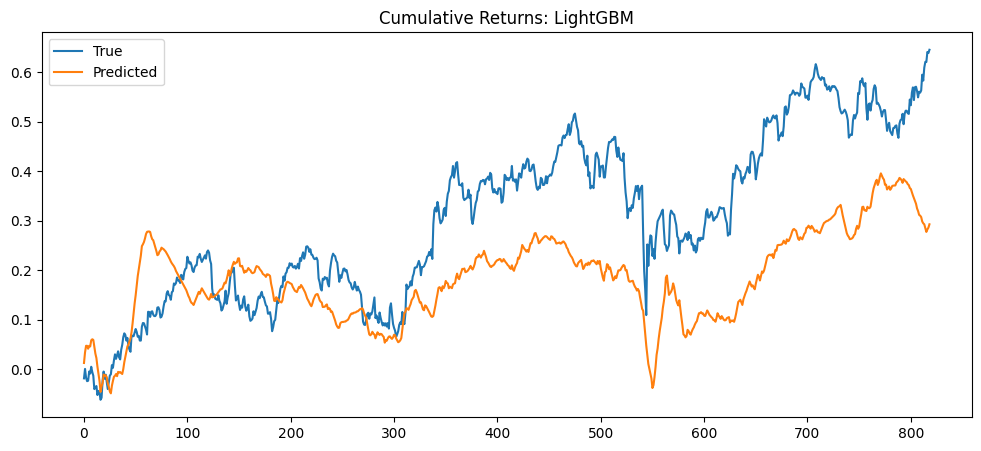

In [2]:

import yfinance as yf
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import lightgbm as lgb

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()
    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volatility"] = df["log_return"].rolling(20).std()
df["momentum"] = df["close"] / df["close"].shift(10) - 1
df["ma10"] = df["close"].rolling(10).mean()
df["ma20"] = df["close"].rolling(20).mean()

df = df.dropna()

y = df["log_return"]
X = df.drop(columns=["log_return"])

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
direction_acc = np.mean(np.sign(y_test) == np.sign(preds))

print("LIGHTGBM RESULTS")
print("RMSE:", rmse)
print("Direction Accuracy:", direction_acc)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(np.cumsum(y_test.values), label="True")
plt.plot(np.cumsum(preds), label="Predicted")
plt.legend()
plt.title("Cumulative Returns: LightGBM")
plt.show()